# Eksperimen Machine Learning - Titanic Dataset

## Informasi Dataset
- **Nama Dataset**: Titanic Dataset
- **Sumber Data**: [Kaggle Titanic Competition](https://www.kaggle.com/c/titanic/data)
- **Deskripsi**: Dataset berisi informasi penumpang kapal Titanic yang tenggelam pada tahun 1912. Dataset ini digunakan untuk memprediksi apakah seorang penumpang selamat atau tidak berdasarkan fitur-fitur yang tersedia.
- **Jumlah Data**: 891 baris, 12 kolom
- **Target Variable**: `Survived` (0 = Tidak Selamat, 1 = Selamat)

## Detail Fitur
| Fitur | Tipe | Deskripsi |
|-------|------|-----------|
| PassengerId | int | ID unik penumpang |
| Pclass | int | Kelas tiket (1, 2, 3) |
| Name | string | Nama penumpang |
| Sex | string | Jenis kelamin |
| Age | float | Usia penumpang |
| SibSp | int | Jumlah saudara/pasangan di kapal |
| Parch | int | Jumlah orang tua/anak di kapal |
| Ticket | string | Nomor tiket |
| Fare | float | Harga tiket |
| Cabin | string | Nomor kabin |
| Embarked | string | Pelabuhan keberangkatan (C, Q, S) |

## Informasi Tambahan
- **Missing Values**: Age (19.9%), Cabin (77.1%), Embarked (0.2%)
- **Class Distribution**: 61.6% Tidak Selamat, 38.4% Selamat
- **Referensi**: Titanic: Machine Learning from Disaster — https://www.kaggle.com/c/titanic

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Data Loading

In [2]:
# Load dataset Titanic dari seaborn
df = sns.load_dataset('titanic')

# Simpan raw dataset
import os
os.makedirs('../titanic_raw', exist_ok=True)
df.to_csv('../titanic_raw/titanic_raw.csv', index=False)

print(f'Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'Kolom: {list(df.columns)}')
df.head()

Dataset berhasil dimuat!
Shape: (891, 15)
Kolom: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Info dasar dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
# Statistik deskriptif
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Percentage': missing_pct})
print('=== Missing Values ===')
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
             Missing Count  Missing Percentage
age                    177           19.865320
embarked                 2            0.224467
deck                   688           77.216611
embark_town              2            0.224467


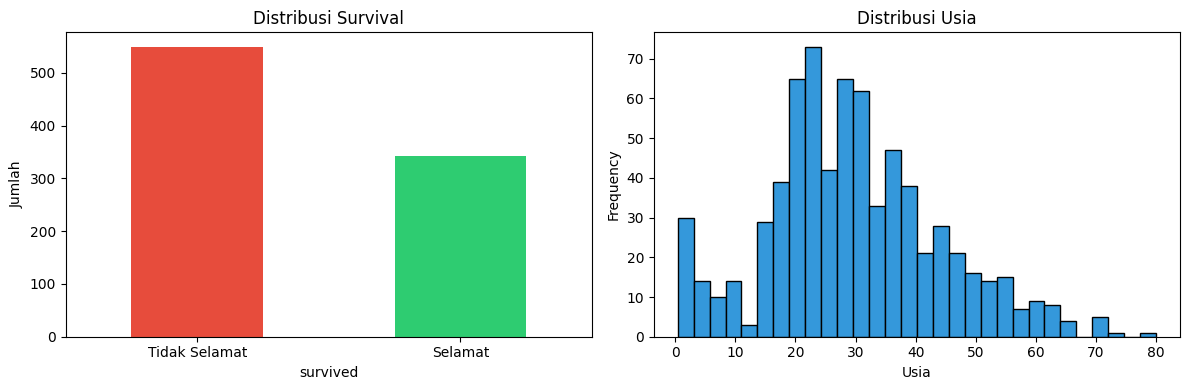

Plot disimpan!


In [11]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi survival
df['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribusi Survival')
axes[0].set_xticklabels(['Tidak Selamat', 'Selamat'], rotation=0)
axes[0].set_ylabel('Jumlah')

# Distribusi usia
df['age'].dropna().plot(kind='hist', ax=axes[1], bins=30, color='#3498db', edgecolor='black')
axes[1].set_title('Distribusi Usia')
axes[1].set_xlabel('Usia')

plt.tight_layout()
plt.savefig('preprocessing/eda_distribusi.png')
plt.show()
print('Plot disimpan!')

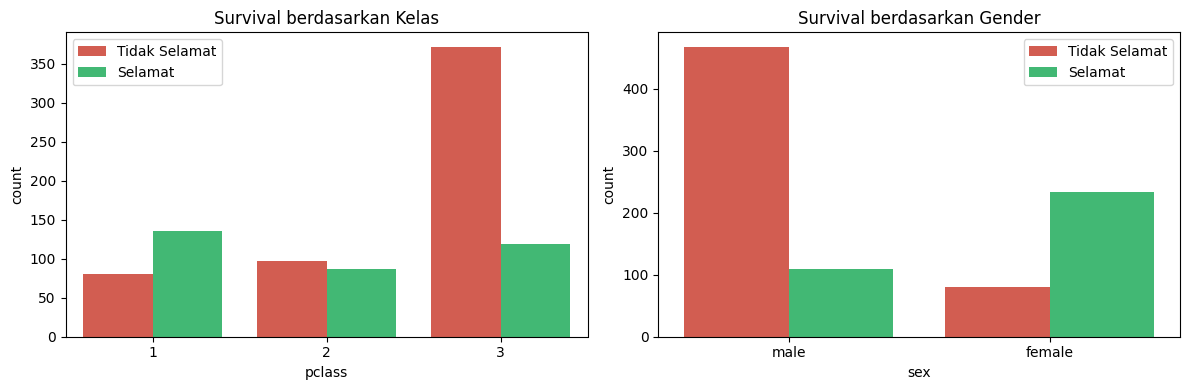

In [12]:
# Survival berdasarkan kelas dan gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='pclass', hue='survived', ax=axes[0],
              palette={0: '#e74c3c', 1: '#2ecc71'})
axes[0].set_title('Survival berdasarkan Kelas')
axes[0].legend(['Tidak Selamat', 'Selamat'])

sns.countplot(data=df, x='sex', hue='survived', ax=axes[1],
              palette={0: '#e74c3c', 1: '#2ecc71'})
axes[1].set_title('Survival berdasarkan Gender')
axes[1].legend(['Tidak Selamat', 'Selamat'])

plt.tight_layout()
plt.savefig('preprocessing/eda_survival.png')
plt.show()

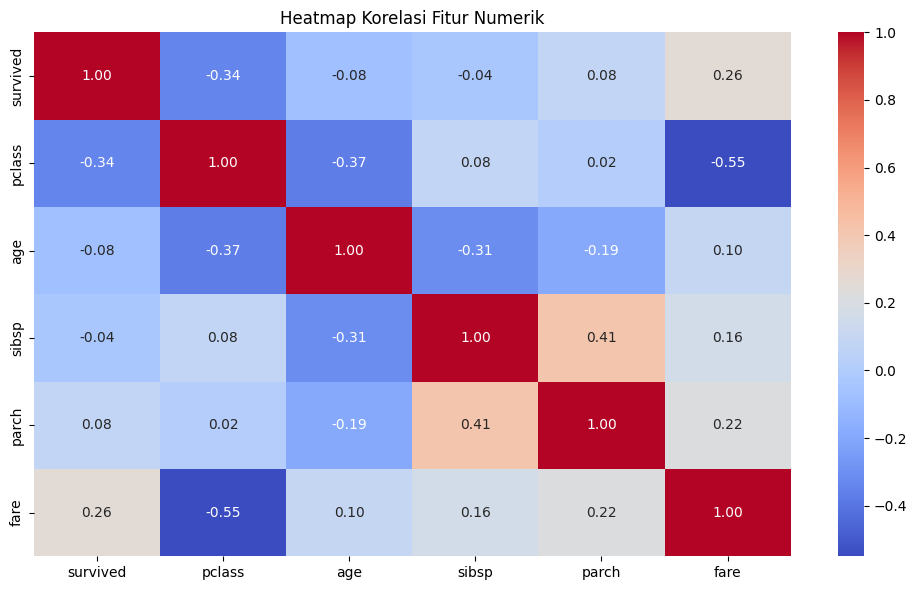

In [13]:
# Heatmap korelasi
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.savefig('preprocessing/eda_korelasi.png')
plt.show()

## 4. Preprocessing

In [14]:
# === STEP 1: Pilih Fitur yang Relevan ===
features = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df_clean = df[features].copy()
print(f'Shape setelah seleksi fitur: {df_clean.shape}')
df_clean.head()

Shape setelah seleksi fitur: (891, 8)


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [15]:
# === STEP 2: Handle Missing Values ===
# Isi age dengan median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Isi embarked dengan modus
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

print('Missing values setelah ditangani:')
print(df_clean.isnull().sum())

Missing values setelah ditangani:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [16]:
# === STEP 3: Encoding Fitur Kategorikal ===
le = LabelEncoder()

# Encode sex: male=1, female=0
df_clean['sex'] = le.fit_transform(df_clean['sex'])

# Encode embarked
df_clean['embarked'] = le.fit_transform(df_clean['embarked'])

print('Setelah encoding:')
df_clean.head()

Setelah encoding:


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [17]:
# === STEP 4: Feature Engineering ===
# Buat fitur family_size
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch']

# Buat fitur is_alone
df_clean['is_alone'] = (df_clean['family_size'] == 0).astype(int)

print(f'Shape setelah feature engineering: {df_clean.shape}')
df_clean.head()

Shape setelah feature engineering: (891, 10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,2,1,0
1,1,1,0,38.0,1,0,71.2833,0,1,0
2,1,3,0,26.0,0,0,7.9250,2,0,1
3,1,1,0,35.0,1,0,53.1000,2,1,0
4,0,3,1,35.0,0,0,8.0500,2,0,1


In [18]:
# === STEP 5: Normalisasi / Scaling ===
scaler = StandardScaler()
cols_to_scale = ['age', 'fare', 'family_size']
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print('Setelah scaling:')
df_clean.describe()

Setelah scaling:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone
count,891.000000,891.000000,891.000000,8.910000e+02,891.000000,891.000000,8.910000e+02,891.000000,8.910000e+02,891.000000
mean,0.383838,2.308642,0.647587,2.272780e-16,0.523008,0.381594,3.987333e-18,1.536476,-3.987333e-18,0.602694
std,0.486592,0.836071,0.477990,1.000562e+00,1.102743,0.806057,1.000562e+00,0.791503,1.000562e+00,0.489615
min,0.000000,1.000000,0.000000,-2.224156e+00,0.000000,0.000000,-6.484217e-01,0.000000,-5.609748e-01,0.000000
25%,0.000000,2.000000,0.000000,-5.657365e-01,0.000000,0.000000,-4.891482e-01,1.000000,-5.609748e-01,0.000000
50%,0.000000,3.000000,1.000000,-1.046374e-01,0.000000,0.000000,-3.573909e-01,2.000000,-5.609748e-01,1.000000
75%,1.000000,3.000000,1.000000,4.333115e-01,1.000000,0.000000,-2.424635e-02,2.000000,5.915988e-02,1.000000
max,1.000000,3.000000,1.000000,3.891554e+00,8.000000,6.000000,9.667167e+00,2.000000,5.640372e+00,1.000000


In [22]:
# === STEP 6: Train-Test Split & Simpan ===
X = df_clean.drop('survived', axis=1)
y = df_clean['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Simpan hasil preprocessing
os.makedirs('preprocessing/titanic_preprocessing', exist_ok=True)

train_df = X_train.copy()
train_df['survived'] = y_train.values
train_df.to_csv('preprocessing/titanic_preprocessing/titanic_train.csv', index=False)

test_df = X_test.copy()
test_df['survived'] = y_test.values
test_df.to_csv('preprocessing/titanic_preprocessing/titanic_test.csv', index=False)

print(f'Train set: {X_train.shape}')
print(f'Test set:  {X_test.shape}')
print('Dataset preprocessing berhasil disimpan!')

Train set: (712, 9)
Test set:  (179, 9)
Dataset preprocessing berhasil disimpan!


## 5. Kesimpulan EDA & Preprocessing

**Temuan EDA:**
- Dataset memiliki 891 baris dan 15 kolom
- Kolom `age` memiliki ~20% missing values → diisi dengan median
- Kolom `embarked` memiliki 2 missing values → diisi dengan modus
- Survival rate sekitar 38% (kelas tidak seimbang)
- Penumpang perempuan dan kelas 1 memiliki tingkat survival lebih tinggi

**Langkah Preprocessing:**
1. Seleksi 8 fitur relevan
2. Imputasi missing values
3. Label Encoding untuk fitur kategorikal
4. Feature Engineering (family_size, is_alone)
5. StandardScaler untuk fitur numerik
6. Train-test split (80:20)

**Output:** File `titanic_train.csv` dan `titanic_test.csv` siap digunakan untuk training model.